In [160]:
import pandas as pd
import matplotlib.pyplot as plt

In [161]:
df = pd.read_csv("titanic.csv")

In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [163]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [164]:
for col in df.columns:
    print(f"Column {col:}")
    print(f"Number of null values: {df[col].isnull().sum()}")
    print(f"mumber of unique values: {df[col].nunique()}")
    print("-------------------------------------------------------")

Column PassengerId
Number of null values: 0
mumber of unique values: 891
-------------------------------------------------------
Column Survived
Number of null values: 0
mumber of unique values: 2
-------------------------------------------------------
Column Pclass
Number of null values: 0
mumber of unique values: 3
-------------------------------------------------------
Column Name
Number of null values: 0
mumber of unique values: 891
-------------------------------------------------------
Column Sex
Number of null values: 0
mumber of unique values: 2
-------------------------------------------------------
Column Age
Number of null values: 177
mumber of unique values: 88
-------------------------------------------------------
Column SibSp
Number of null values: 0
mumber of unique values: 7
-------------------------------------------------------
Column Parch
Number of null values: 0
mumber of unique values: 7
-------------------------------------------------------
Column Ticket
Number

In [165]:
print(f"Number of duplicates: {df.duplicated().sum()}")

Number of duplicates: 0


In [166]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [167]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [168]:
categorical_features = ["Survived","Sex","Pclass","Embarked"]
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_features)
print(categorical_features)

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
['Survived', 'Sex', 'Pclass', 'Embarked']


In [169]:
for col in categorical_features:
    df[col] = df[col].astype('category')

In [170]:
for col in categorical_features:
    print(f"Column {col}:")
    print(df[col].value_counts())
    print("------------------------------")

Column Survived:
Survived
0    549
1    342
Name: count, dtype: int64
------------------------------
Column Sex:
Sex
male      577
female    314
Name: count, dtype: int64
------------------------------
Column Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
------------------------------
Column Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
------------------------------


In [172]:
df[df['Age'] < 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S


In [173]:
not_int_ages = df[df['Age'].notnull() & (df['Age'] % 1 != 0)]
not_int_ages['Age']

57     28.50
78      0.83
111    14.50
116    70.50
122    32.50
123    32.50
148    36.50
152    55.50
153    40.50
203    45.50
227    20.50
296    23.50
305     0.92
331    45.50
469     0.75
525    40.50
644     0.75
676    24.50
735    28.50
755     0.67
767    30.50
803     0.42
814    30.50
831     0.83
843    34.50
Name: Age, dtype: float64

In [174]:
df.set_index('PassengerId', inplace=True)

In [175]:
import numpy as np
df.loc[(df['Age'] >= 0) & (df['Age'] < 1), 'Age'] = np.nan
df.loc[df['Age'].notnull() & (df['Age'] % 1 != 0), 'Age'] = df.loc[df['Age'].notnull() & (df['Age'] % 1 != 0), 'Age'].round()

In [176]:
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100
null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percentages
})
null_summary = null_summary[null_summary['Null Count'] > 0]
print(null_summary)

          Null Count  Null Percentage
Age              184        20.650954
Cabin            687        77.104377
Embarked           2         0.224467


In [177]:
df.drop(columns='Cabin', inplace=True)
df['Embarked'] = df['Embarked'].fillna('S')

In [178]:
age_median=df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)

In [179]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Name      891 non-null    str     
 3   Sex       891 non-null    category
 4   Age       891 non-null    float64 
 5   SibSp     891 non-null    int64   
 6   Parch     891 non-null    int64   
 7   Ticket    891 non-null    str     
 8   Fare      891 non-null    float64 
 9   Embarked  891 non-null    category
dtypes: category(4), float64(2), int64(2), str(2)
memory usage: 45.6 KB


In [180]:
import matplotlib.pyplot as plt

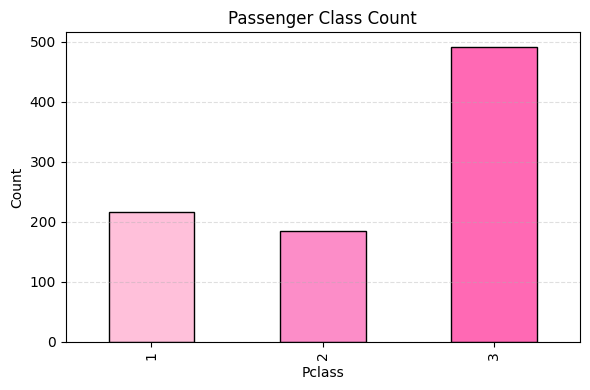

In [181]:
plt.figure(figsize=(6,4))
colors = ["#FFC0DA", "#FC8DC8", "#FF69B4"]  
df['Pclass'].value_counts().sort_index().plot(kind='bar', color = colors , edgecolor="black")
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.title('Passenger Class Count')
plt.tight_layout()
plt.show()

Sex
male      577
female    314
Name: count, dtype: int64


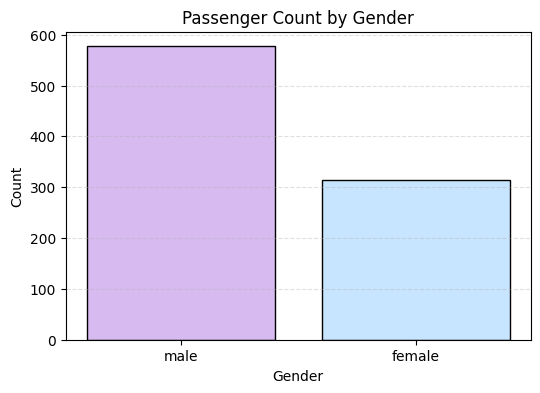

In [182]:
gender_counts = df['Sex'].value_counts()
print(gender_counts)
plt.figure(figsize=(6,4))
colors = ["#D7BAF0", "#C8E5FF"] 
bars = plt.bar(gender_counts.index, gender_counts.values,color=colors, edgecolor='black')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Passenger Count by Gender')
plt.grid(axis='y', linestyle='--', alpha=0.4)

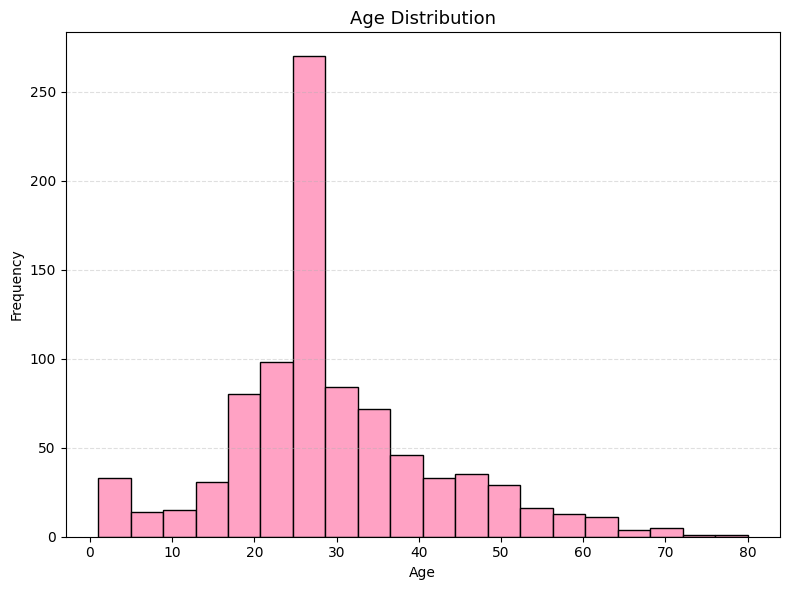

In [183]:
plt.figure(figsize=(8,6))
plt.hist(df['Age'], bins=20, color="#FFA2C4", edgecolor="black")
plt.title('Age Distribution', fontsize=13)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


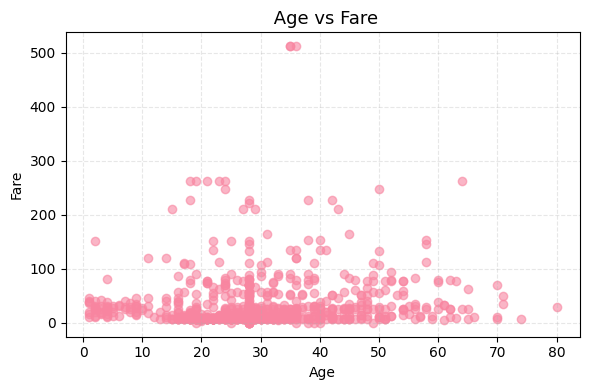

In [184]:
plt.figure(figsize=(6,4))
plt.scatter(df['Age'], df['Fare'], color="#F885A0", alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title(' Age vs Fare', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


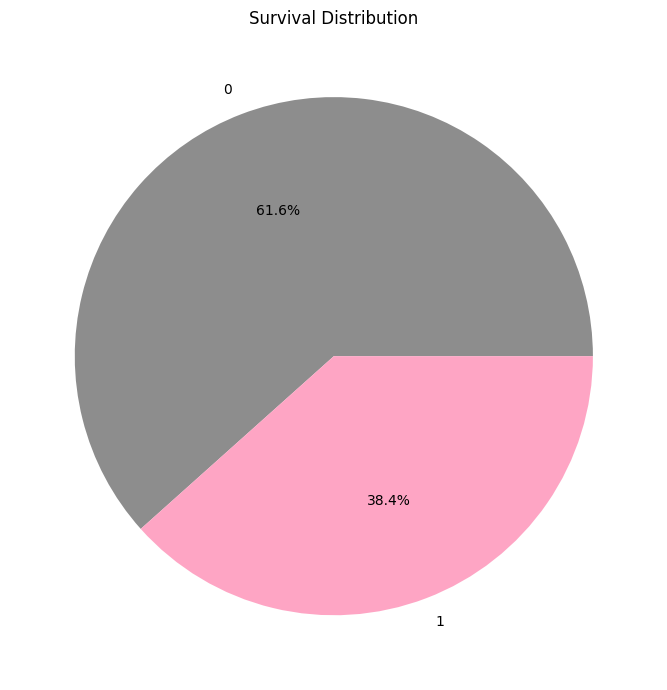

In [185]:
plt.figure(figsize=(7,7))
x = df['Survived'].value_counts()
x.plot(kind='pie',autopct='%1.1f%%',colors=["#8D8D8D", "#FEA5C4"])
plt.title('Survival Distribution')
plt.tight_layout()
plt.show()


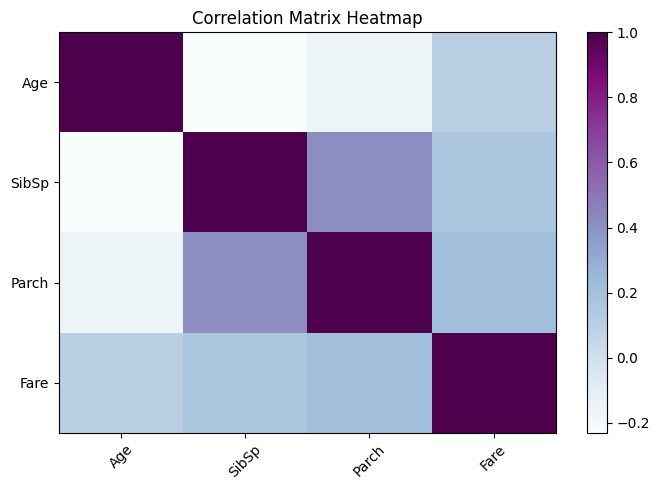

            Age     SibSp     Parch      Fare
Age    1.000000 -0.230507 -0.157075  0.100422
SibSp -0.230507  1.000000  0.414838  0.159651
Parch -0.157075  0.414838  1.000000  0.216225
Fare   0.100422  0.159651  0.216225  1.000000


In [186]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(7,5))
plt.imshow(corr_matrix, aspect='auto', cmap='BuPu')
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.colorbar()
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()
print(corr_matrix)

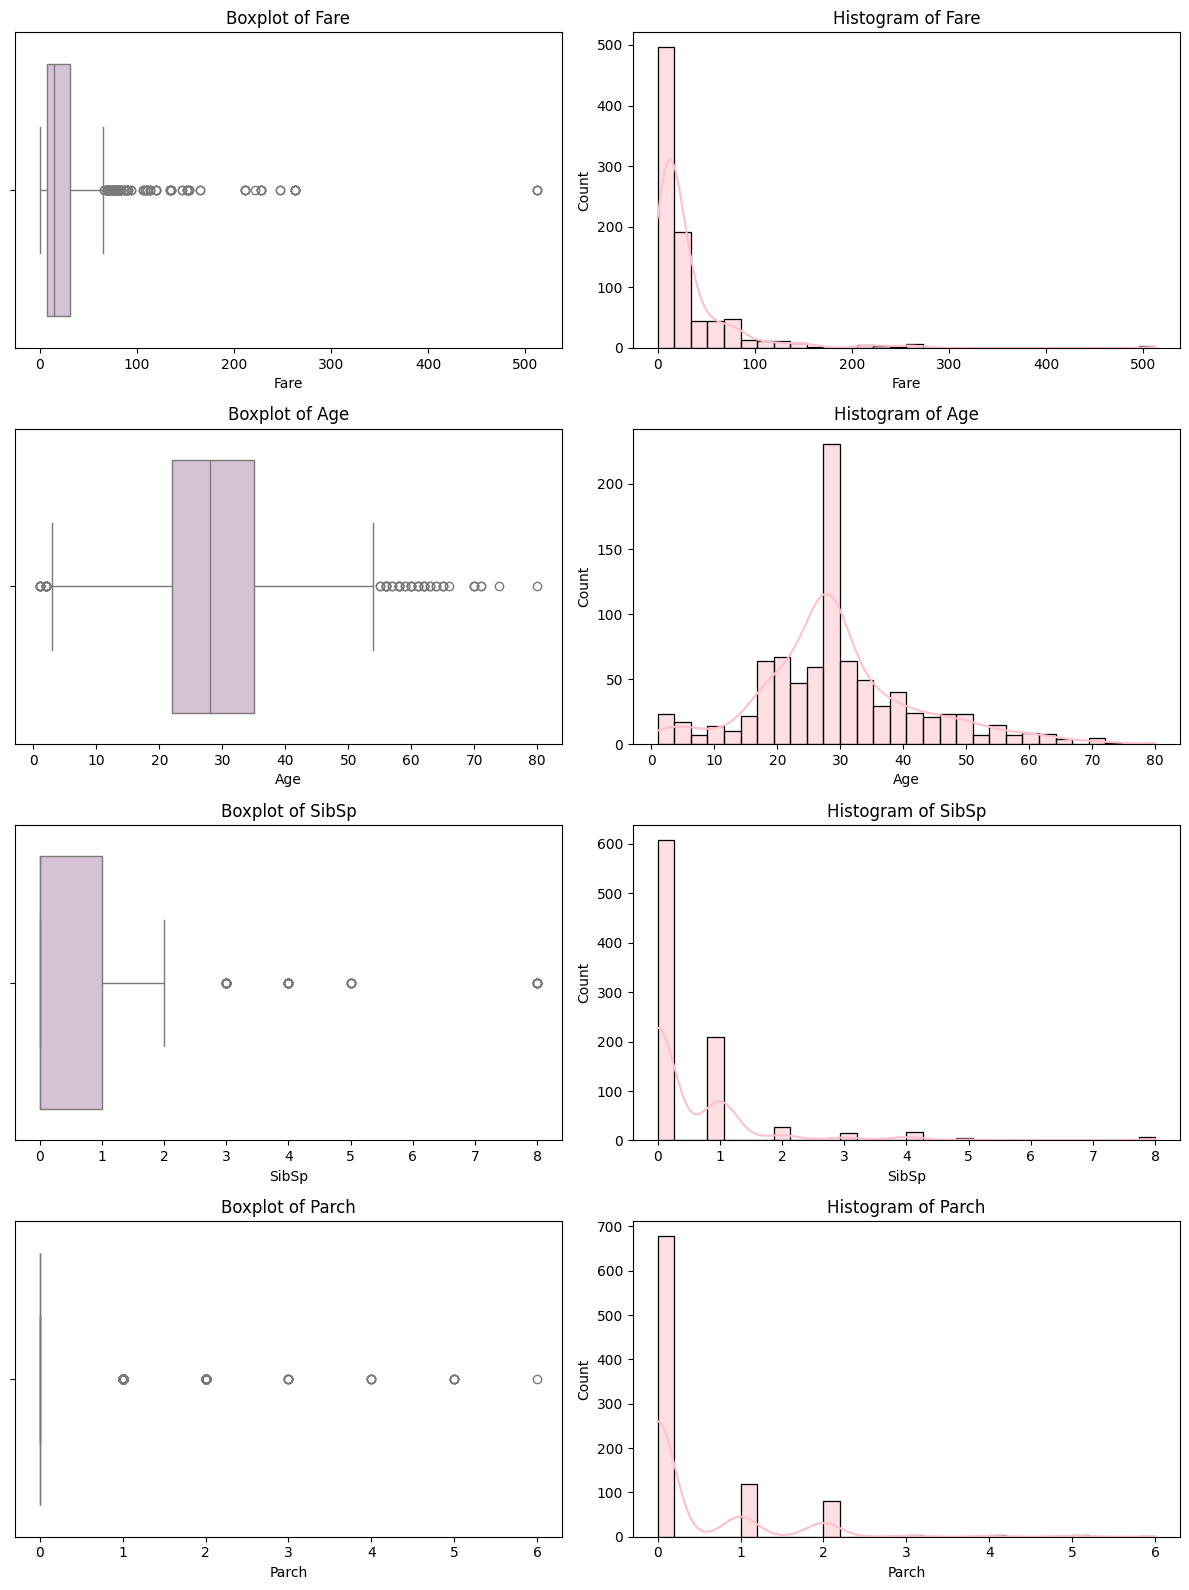

In [189]:
import seaborn as sns
numerical_features=['Fare', 'Age', 'SibSp', 'Parch']
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, 4 * len(numerical_features)))
for i, col in enumerate(numerical_features):
    sns.boxplot(x=df[col], ax=axes[i, 0], color='thistle')
    axes[i, 0].set_title(f'Boxplot of {col}')

    sns.histplot(df[col], bins=30, ax=axes[i, 1], kde=True, color='pink')
    axes[i, 1].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()